In [ ]:
### Created by Myongin Oh
### Last updated on Aug 23, 2025

In [ ]:
##### User inputs #####
nDataPoints = 10000  # Number of data points for each class (*note: each class should have the same number of data points)
dataset = 'output_dist_res_merged.csv'  # Dataset to analyze
nclasses = 3  # Number of classes in the dataset

In [ ]:
### STEP 0. Import libraries
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
import matplotlib.pyplot as plt
import gc
import seaborn as sns
import kneed

In [ ]:
dfDist = pd.read_csv(dataset)

In [4]:
### STEP 1. Remove columns with low variance (remove constant and quasi-constant columns)
variance_values = dfDist.var()
variance_plot = sorted(variance_values, reverse=True)

In [8]:
from kneed import KneeLocator

x = range(1, len(variance_plot) + 1)

# Find the knee point
knee_locator = KneeLocator(x, variance_plot, curve='convex', direction='decreasing', S=200)
knee_point = knee_locator.knee  # This is the x value of the knee point

print(f"The knee point is at x (nFeat) = {knee_point}, and score of: {knee_locator.knee_y}")

The knee point is at x (nFeat) = 4426, and score of: 0.45689852264465186


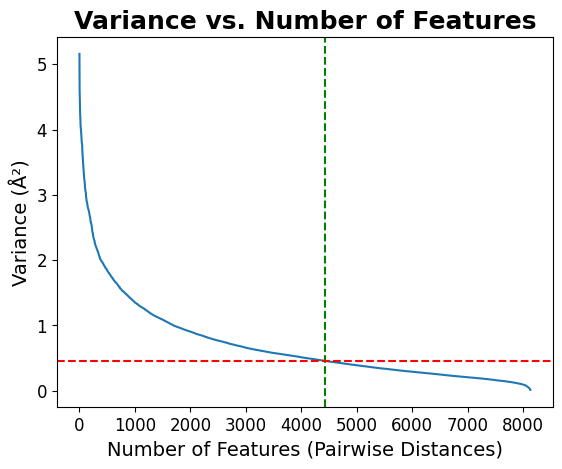

In [9]:
varThresh = knee_locator.knee_y
plt.plot(variance_plot)
# Edit according to new threshold
plt.axvline(x=knee_point, color='g', linestyle='--')
plt.axhline(y=varThresh, color='r', linestyle='--')
plt.xlabel('Number of Features (Pairwise Distances)', fontsize=14)
plt.ylabel('Variance (Å²)', fontsize=14)
plt.title('Variance vs. Number of Features', fontweight='bold', fontsize=18)
# Edit according to new threshold 
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
#plt.savefig('./variance_CA.pdf', dpi=300)
plt.show()

In [10]:
gc.collect()
var_thres = VarianceThreshold(threshold=varThresh) 
var_thres.fit(dfDist)
new_cols = var_thres.get_support()
concol = [column for column in dfDist.columns if column not in dfDist.columns[new_cols]]
variance_values = dfDist.var()
print("We have", len(concol), "columns with low variance")
print("out of", len(variance_values), "total columns.")

We have 3703 columns with low variance
out of 8128 total columns.


In [11]:
dfReduced = dfDist.drop(concol,axis=1)
dfReduced.shape

(30000, 4425)

In [13]:
### STEP 4. Add classes and export as csv 
zeroList = [0]*nDataPoints # class 1
oneList = [1]*nDataPoints # class 2
twoList = [2]*nDataPoints # class 3
dfReduced['class'] = np.array(zeroList + oneList + twoList)

In [14]:
dfReduced.to_csv('output_dist_res_with_class_post_var.csv', encoding='utf-8', index=False)

In [ ]:
del dfDist
del dfReduced
del dfReduced_minmax
del dfReduced_standard